# **GEOL415 Lab 3**

Welcome to lab 3. This week will be a bit more free-form. 

**RECAP.** Last week, you:
- gained more experience with terminal commands.
- downloaded and properly imported tabular ice core data.
- analyzed said dataset.

**PREVIEW.** This week, you will:
- Look through a curated list of datasets provided to you by us.
- Select one you find interesting for your course project pitch next week.

As a reminder, this project will be:

**"...a data analysis report (5 pages single spaced, 0.5 inch margins, 12pt Arial font, at least 5 figures) and presentation on an earth and environmental science research topic. A grading rubric will be provided for the final project. The assignment is scaffolded throughout the semester with
intermediate due dates.'**

## **Select a dataset from the following options**
I will go through a couple of these with the class. Feel free to follow along or explore these on your own. 

# **Air Quality**

1. [EPA AQS pre-generated files](https://aqs.epa.gov/aqsweb/airdata/download_files.html) : hourly/daily pollutant concentrations from thousands of US monitors, by year and pollutant.

2. [OpenAQ](openaq.org) : global ground-station air quality data, API plus bulk archives. 

# **Weather/Climate**

1. [NOAA GHCN-Daily](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00861): daily temperature, precipitation, snowfall from tens of thousands of stations worldwide.

2. [Berkeley Earth land temperature data](https://berkeleyearth.org/data/): cleaned, gridded and station-level temperature records.

# **Hydrology**
1. [USGS NWIS](https://waterdata.usgs.gov/): streamflow, gauge height, water quality from thousands of US gauges.

2. [CAMELS](https://ral.ucar.edu/dataset/camels-catchment-attributes-and-meteorology-large-sample-studies-dataset-downloads): 671 US catchments with matched streamflow and meteorological forcing


 # **Ecology and biodiversity**
1. [GBIF](https://www.gbif.org/): hundreds of millions of species occurrence records, simple download and filter interface.

2. [eBird Basic Dataset](https://science.ebird.org/use-ebird-data/download-ebird-data-products): citizen-science bird sightings with location, date, observer effort.

3. [GRooT](https://groot-database.github.io/GRooT/): global root trait database compiling measurements across thousands of plant species.


# **Land cover and remote sensing**

1. [ESA WorldCover](https://esa-worldcover.org/en): global 10m land cover classification, accessible through Google Earth Engine.
2. [NASA FIRMS active fire data](https://firms.modaps.eosdis.nasa.gov/active_fire/): daily fire detections

# **Ocean and marine**
1. [NOAA National Data Buoy Center](https://www.ndbc.noaa.gov/): hourly wind, wave, and temperature observations from moored buoys.
2. [Argo float profiles](https://argo.ucsd.edu/): temperature and salinity profiles from autonomous floats, with the ```argopy``` package for querying.


# **Deliverable for today's lab**

1. Write down which dataset you chose to work with in a markdown cell below. 
2. Load up a pd.DataFrame of a dataset of your choosing.
3. Give me **ONE** summary statistic, visualization, etc. of the data.

**If you already have data to work with**: Do 1-3 with that.

1. Will be working with TEMPO ozone profile V04 data

In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
 
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# looking at Big Grass Fire in Oregon
# coordinates:
# SW: 41.8,-118.0
# NE: 43.1,-116.7
SW_LAT, SW_LON = 41.8, -118.0
NE_LAT, NE_LON = 43.1, -116.7
LAT_MIN, LAT_MAX = SW_LAT, NE_LAT
LON_MIN, LON_MAX = SW_LON, NE_LON


2. Loading the data below:

In [10]:
path="project/TEMPO_O3PROF_L2_V04_20260911T192124Z_S010G08.nc"

In [11]:
ds = nc.Dataset(path)

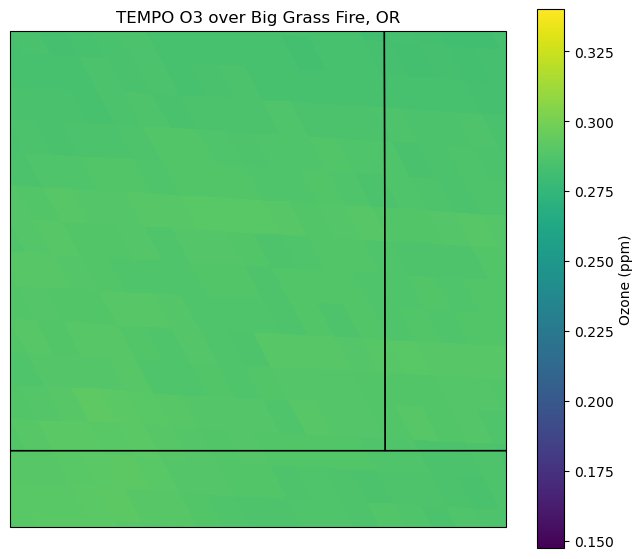

In [15]:
lat = ds["geolocation"]["latitude"][:]
lon = ds["geolocation"]["longitude"][:]
o3 = ds["product"]["ozone_profile"][:]

if o3.ndim == lat.ndim + 1:
    o3 = o3.sum(axis=-1)

plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES)

o3_ppm = o3 / 1000.0
plt.pcolormesh(lon, lat, o3_ppm, cmap="viridis", shading="auto", transform=ccrs.PlateCarree())
plt.colorbar(label="Ozone (ppm)")
plt.title("TEMPO O3 over Big Grass Fire, OR")
plt.show()

3. Visualization of ozone in ppm over the region of the Big Grass Fire on September 11th (near the end of the fire's containment)